# Project Portofolio

Naufal Mushthofa | Hp/WhatsApp : 089530070769 | Email : naufalmusthofa6696@gmail.com

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv("dataset/customer.csv")
orders = pd.read_csv("dataset/orders.csv")
product = pd.read_csv("dataset/product.csv")
region = pd.read_csv("dataset/region.csv")
shipment = pd.read_csv("dataset/shipment.csv")

In [3]:
# run 1 by 1
#customer.head()
orders.head()
#product.head()
#region.head()
#shipment.head()

,order_id,customer_id,postal_code,product_id,sales,quantity,discount,profit
0,CA-2019-152156,CG-12520,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2019-152156,CG-12520,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2019-138688,DV-13045,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2018-108966,SO-20335,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2018-108966,SO-20335,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164


# Data Quality

In [4]:
# run 1 by 1
#customer.info()
orders.info()
#product.info()
#region.info()
#shipment.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     9994 non-null   str    
 1   customer_id  9994 non-null   str    
 2   postal_code  9994 non-null   int64  
 3   product_id   9994 non-null   str    
 4   sales        9994 non-null   float64
 5   quantity     9994 non-null   int64  
 6   discount     9994 non-null   float64
 7   profit       9994 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 624.8 KB


In [5]:
# run 1 by 1
#customer.isnull().sum()
orders.isnull().sum()
#product.isnull().sum()
#region.isnull().sum()
#shipment.isnull().sum()

order_id       0
customer_id    0
postal_code    0
product_id     0
sales          0
quantity       0
discount       0
profit         0
dtype: int64

In [6]:
# run 1 by 1
#customer.duplicated().sum()
orders.duplicated().sum()
#product.duplicated().sum()
#region.duplicated().sum()
#shipment.duplicated().sum()

np.int64(1)

In [7]:
orders[orders.duplicated(keep=False)]

,order_id,customer_id,postal_code,product_id,sales,quantity,discount,profit
3405,US-2017-150119,LB-16795,43229,FUR-CH-10002965,281.372,2,0.3,-12.0588
3406,US-2017-150119,LB-16795,43229,FUR-CH-10002965,281.372,2,0.3,-12.0588


In [8]:
orders = orders.drop_duplicates()

In [9]:
orders.duplicated().sum()

np.int64(0)

# Profitability by Region & Category

In [10]:
df = orders.merge(region, on="postal_code", how="left") \
           .merge(product, on="product_id", how="left")

In [11]:
profit_region_category = df.groupby(
    ["region","category"]
).agg(
    total_sales=("sales","sum"),
    total_profit=("profit","sum")
).reset_index()

profit_region_category.sort_values("total_profit")

,region,category,total_sales,total_profit
0,Central,Furniture,163797.1638,-2871.0494
3,East,Furniture,208009.8320,3058.2246
6,South,Furniture,117298.6840,6771.2061
1,Central,Office Supplies,167026.4150,8879.9799
9,West,Furniture,252612.7435,11504.9503
7,South,Office Supplies,125651.3130,19986.3928
8,South,Technology,148771.9080,19991.8314
2,Central,Technology,170416.3120,33697.4320
4,East,Office Supplies,205516.0550,41014.5791
11,West,Technology,251991.8320,44303.6496


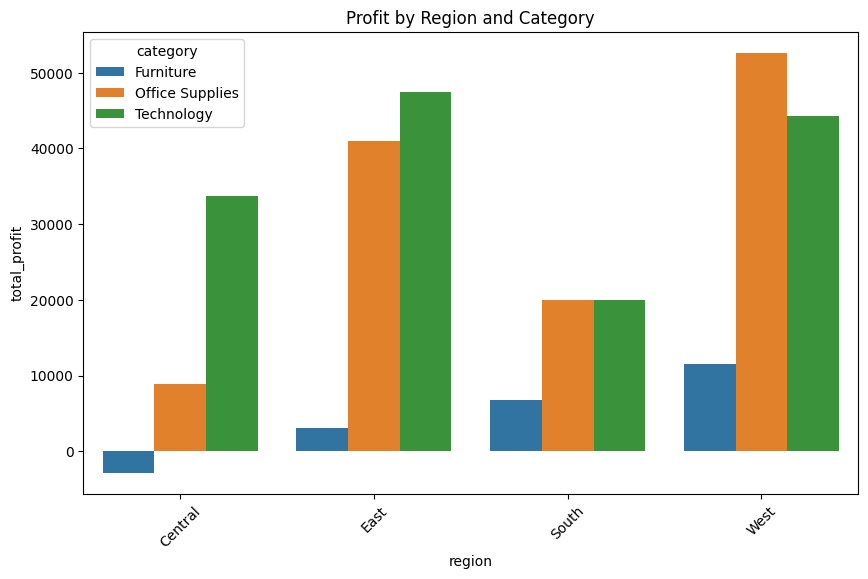

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=profit_region_category,
            x="region",
            y="total_profit",
            hue="category")

plt.title("Profit by Region and Category")
plt.xticks(rotation=45)
plt.show()

# Korelasi Discount & Profit Pada Kategori Furniture di Region Central

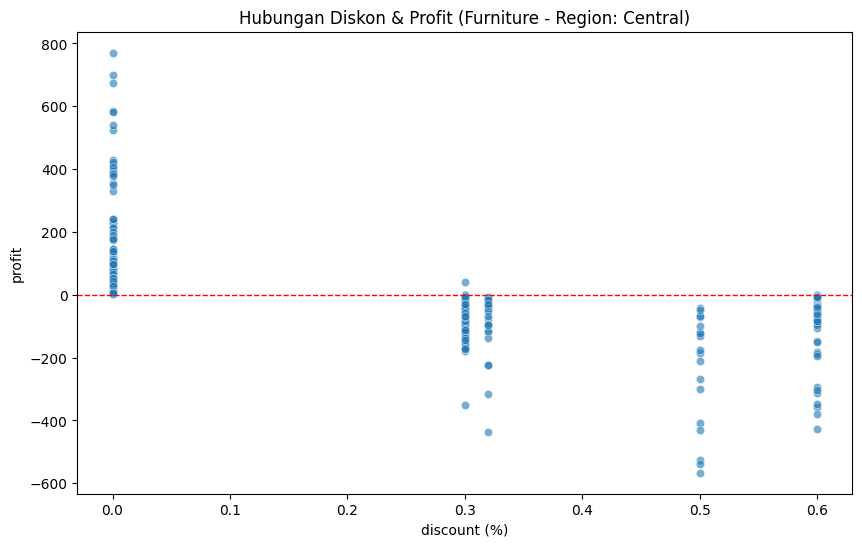

In [13]:
df_merged = orders.merge(product, on='product_id', how='left')
df_merged = df_merged.merge(region.drop_duplicates(subset=['postal_code']), on='postal_code', how='left')
furniture_central = df_merged[(df_merged['category'] == 'Furniture') & (df_merged['region'] == 'Central')]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=furniture_central, x='discount', y='profit', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Hubungan Diskon & Profit (Furniture - Region: Central)')
plt.xlabel('discount (%)')
plt.ylabel('profit')
plt.show()

# Top 10 Customer CLV

In [14]:
clv = orders.merge(customer, on="customer_id")

top10 = clv.groupby(
    ["customer_id","customer_name","segment"]
).agg(
    total_sales=("sales","sum"),
    total_profit=("profit","sum")
).reset_index()

top10 = top10.sort_values("total_profit", ascending=False).head(10)
top10

,customer_id,customer_name,segment,total_sales,total_profit
741,TC-20980,Tamara Chand,Corporate,19052.218,8981.3239
621,RB-19360,Raymond Buch,Consumer,15117.339,6976.0959
669,SC-20095,Sanjit Chand,Consumer,14142.334,5757.4119
327,HL-15040,Hunter Lopez,Consumer,12873.298,5622.4292
6,AB-10105,Adrian Barton,Consumer,14473.571,5444.8055
730,TA-21385,Tom Ashbrook,Home Office,14595.620,4703.7883
160,CM-12385,Christopher Martinez,Consumer,8954.020,3899.8904
424,KD-16495,Keith Dawkins,Corporate,8181.256,3038.6254
48,AR-10540,Andy Reiter,Consumer,6608.448,2884.6208
234,DR-12940,Daniel Raglin,Home Office,8350.868,2869.0760


# Shipping Efficiency

In [15]:
shipment["order_date"] = pd.to_datetime(shipment["order_date"])
shipment["ship_date"] = pd.to_datetime(shipment["ship_date"])

shipment["shipping_days"] = (
    shipment["ship_date"] - shipment["order_date"]
).dt.days

In [16]:
shipment.groupby("ship_mode")["shipping_days"].agg(["mean","min","max"])

,mean,min,max
ship_mode,,,
First Class,2.186785,1,4
Same Day,0.045455,0,1
Second Class,3.231328,1,5
Standard Class,5.002672,3,8


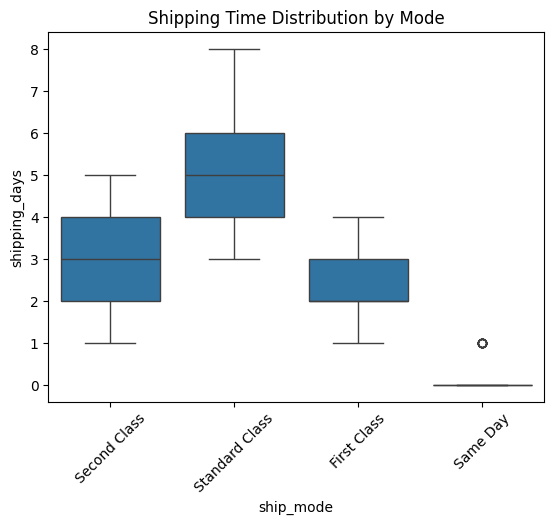

In [17]:
sns.boxplot(data=shipment, x="ship_mode", y="shipping_days")
plt.xticks(rotation=45)
plt.title("Shipping Time Distribution by Mode")
plt.show()

# Discount Impact Analysis

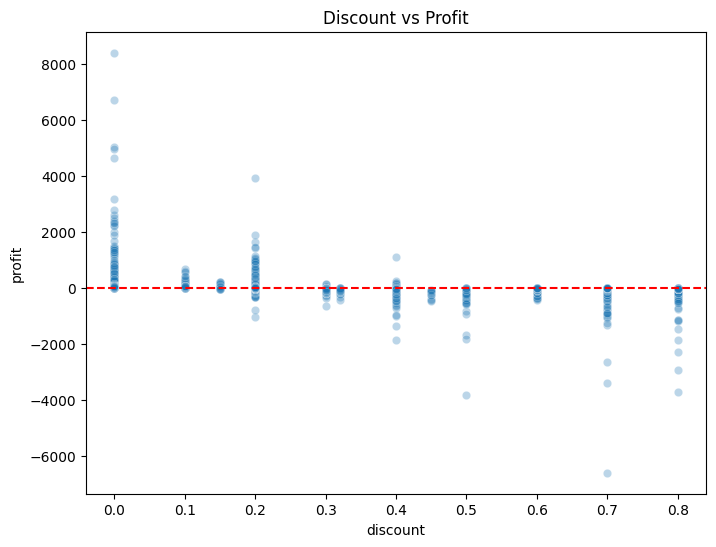

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=orders, x="discount", y="profit", alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.title("Discount vs Profit")
plt.show()

In [19]:
orders[["discount","sales","profit"]].corr()

,discount,sales,profit
discount,1.000000,-0.028197,-0.219481
sales,-0.028197,1.000000,0.479067
profit,-0.219481,0.479067,1.000000


In [20]:
discount_analysis = orders.groupby("discount").agg(
    avg_profit=("profit","mean"),
    total_profit=("profit","sum"),
    count=("profit","count")
).reset_index()

discount_analysis.sort_values("discount")

,discount,avg_profit,total_profit,count
0,0.00,66.900292,320987.6032,4798
1,0.10,96.055074,9029.1770,94
2,0.15,27.288298,1418.9915,52
3,0.20,24.702572,90337.3060,3657
4,0.30,-45.828401,-10357.2186,226
5,0.32,-88.560656,-2391.1377,27
6,0.40,-111.927429,-23057.0504,206
7,0.45,-226.646464,-2493.1111,11
8,0.50,-310.703456,-20506.4281,66
9,0.60,-43.077212,-5944.6552,138


# Time-Series Sales Trend

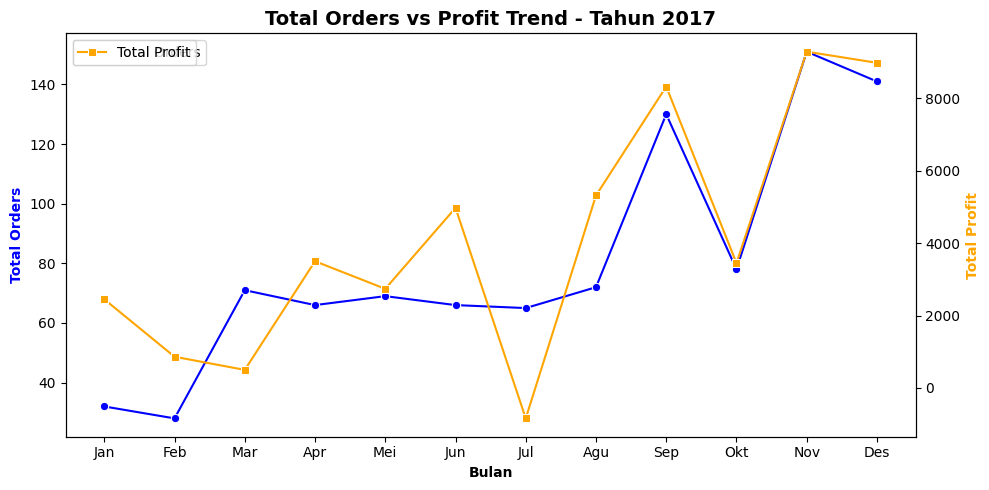

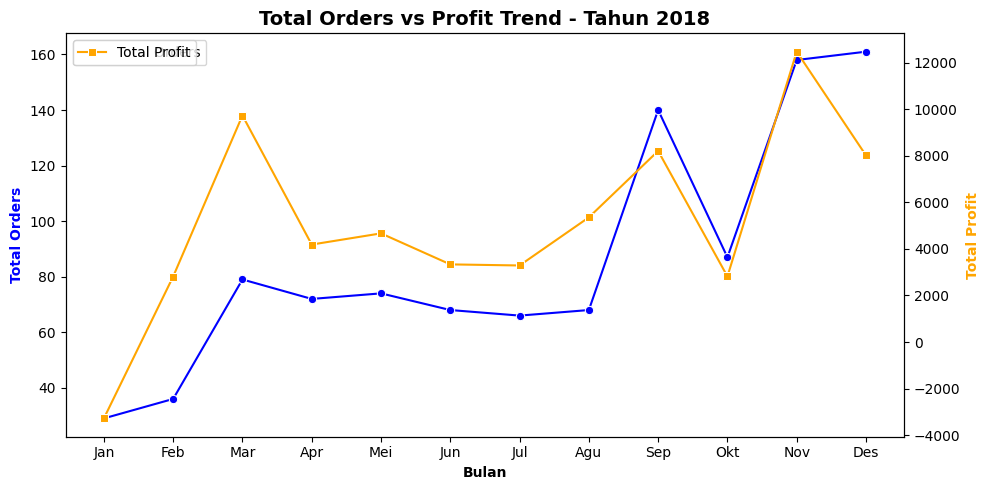

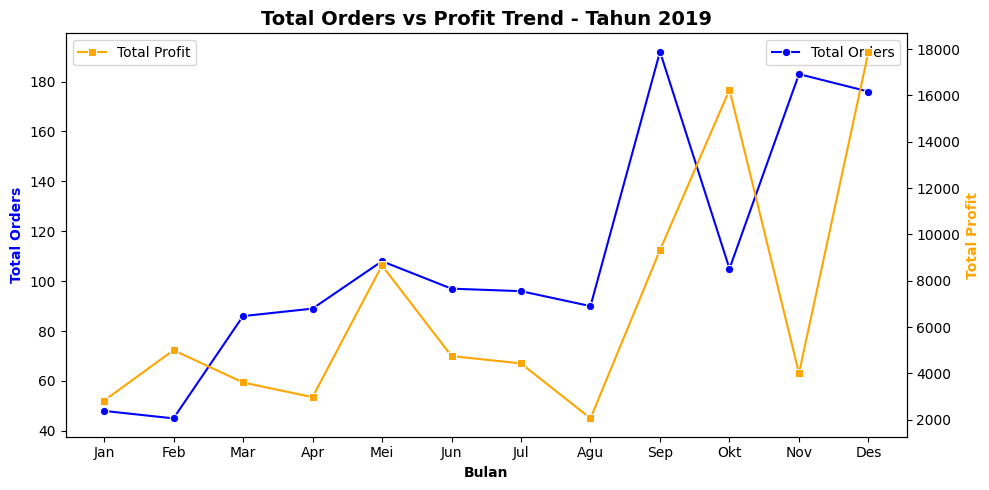

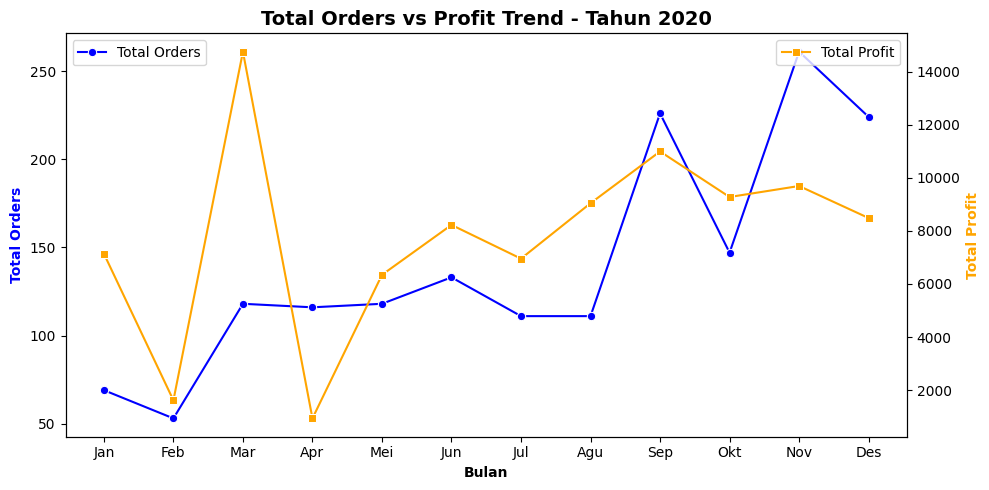

In [21]:
df = orders.merge(shipment, on='order_id', how='left')

df['order_date'] = pd.to_datetime(df['order_date'])

month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

def plot_yearly_trend(year):
    # Filter data berdasarkan tahun
    df_year = df[df["order_date"].dt.year == year].copy()
    df_year["month"] = df_year["order_date"].dt.month
    
    monthly_data = df_year.groupby("month").agg(
        total_orders=("order_id", "nunique"),
        total_profit=("profit", "sum")
    ).reset_index()

    monthly_data['month_name'] = monthly_data['month'].map(month_map)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    sns.lineplot(data=monthly_data, x='month_name', y='total_orders', ax=ax1, color='blue', marker='o', label='Total Orders')
    ax1.set_ylabel('Total Orders', color='blue', fontweight='bold')
    ax1.set_xlabel('Bulan', fontweight='bold')
    
    ax2 = ax1.twinx()
    sns.lineplot(data=monthly_data, x='month_name', y='total_profit', ax=ax2, color='orange', marker='s', label='Total Profit')
    ax2.set_ylabel('Total Profit', color='orange', fontweight='bold')
    
    plt.title(f"Total Orders vs Profit Trend - Tahun {year}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    
for y in [2017, 2018, 2019, 2020]:
    plot_yearly_trend(y)

# Customer Segment Profilling

In [22]:
df_segment = orders.merge(customer, on="customer_id")

In [23]:
segment_perf = df_segment.groupby("segment").agg(
    avg_sales=("sales","mean"),
    total_profit=("profit","sum"),
    total_transactions=("order_id","count")
).reset_index()

segment_perf

,segment,avg_sales,total_profit,total_transactions
0,Consumer,223.733644,134119.2092,5191
1,Corporate,233.823300,91979.1340,3020
2,Home Office,240.949370,60310.7373,1782


In [24]:
segment_perf["transaction_pct"] = (
    segment_perf["total_transactions"] /
    segment_perf["total_transactions"].sum() * 100
)

segment_perf

,segment,avg_sales,total_profit,total_transactions,transaction_pct
0,Consumer,223.733644,134119.2092,5191,51.946362
1,Corporate,233.823300,91979.1340,3020,30.221155
2,Home Office,240.949370,60310.7373,1782,17.832483


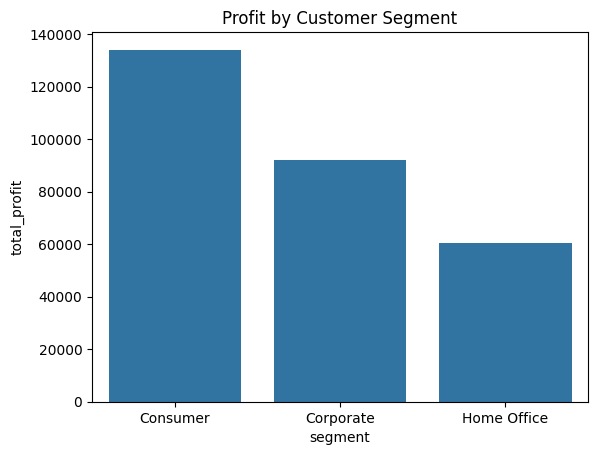

In [25]:
sns.barplot(data=segment_perf, x="segment", y="total_profit")
plt.title("Profit by Customer Segment")
plt.show()

# Korelasi Antar Variabel Finansial

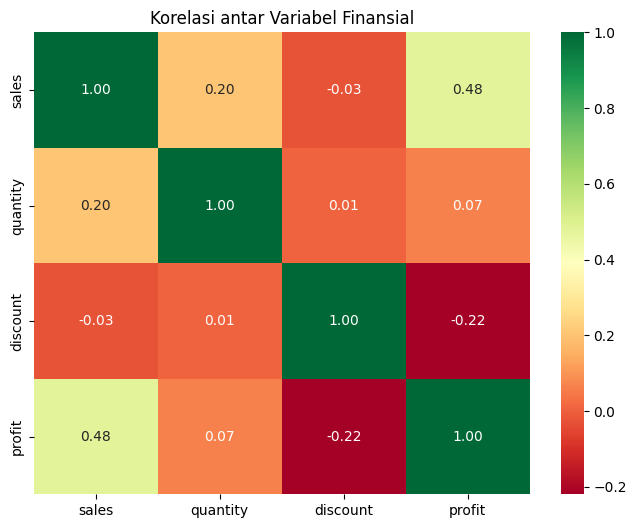

In [26]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_merged[['sales', 'quantity', 'discount', 'profit']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi antar Variabel Finansial')
plt.show()

# Percentage Customer Retention

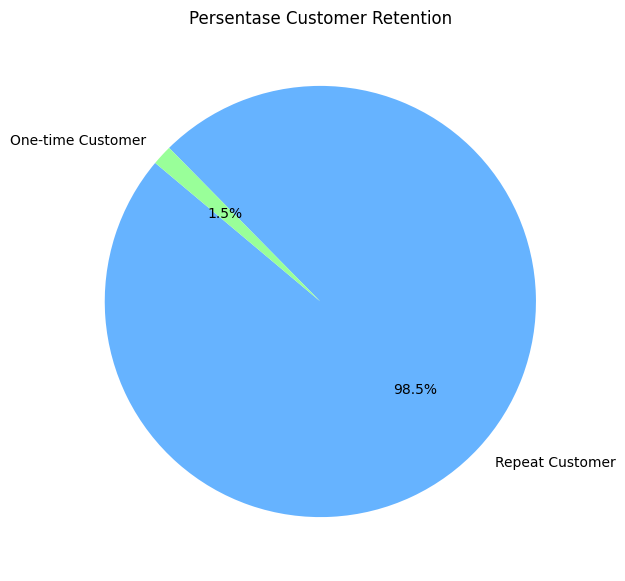

In [27]:
df_merged = orders.merge(customer, on='customer_id', how='left')
customer_orders = df_merged.groupby('customer_name')['order_id'].nunique().reset_index()
customer_orders['Order_Type'] = np.where(customer_orders['order_id'] > 1, 'Repeat Customer', 'One-time Customer')

# Persentase
retention_rate = customer_orders['Order_Type'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))
plt.pie(retention_rate, labels=retention_rate.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99'])
plt.title('Persentase Customer Retention')
plt.show()